In [186]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import pickle
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import re
def extract_mouse_day(fname):
    match = re.search(r'M(\d+)_D(\d+)', fname)
    if match:
        mouse = int(match.group(1))
        day = int(match.group(2))
        return mouse, day
    else:
        return None, None

def get_trial_labels(mouse,day,fig_path='/Users/harryclark/Documents/figs/FIGURE1/'):
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
    mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x') 
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')

    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                    figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

    # we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
    # as defined by activity in the open field
    g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
    cluster_ids_by_group = []
    cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
    cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
    cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
    cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
    cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]
    
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
    dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(pos_in_time)):
        series = pd.Series(dt_in_time)
        filled_series = series.ffill().bfill()
        dt_in_time = np.array(filled_series)
        pos_in_time = dt_in_time%tl
        trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(speed_in_time)):
        series = pd.Series(speed_in_time)
        filled_series = series.ffill().bfill()
        speed_in_time = np.array(speed_in_time)

    # compute the spectrogram and labels from the most adunant grid module
    peak_indices = [28, 44, 60, 76]
    if len(g_m_cluster_ids)>0:
        cluster_ids = g_m_cluster_ids[0]
        got_from_grid = True
    else:
        cluster_ids = cluster_ids_by_group[1]
        got_from_grid = False
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    #max_peaks = np.argmax(S[20:], axis=0) + 20
    labels = np.isin(max_peaks, peak_indices).astype(int)

    plt.figure(figsize=(4, 4))
    plt.imshow(S)
    plt.plot(max_peaks, color='red', linewidth=2, label='max_peaks')
    plt.tight_layout()
    plt.show()

    # compute trial labels for task anchoring to use in the xgboost model mask
    tc = tcs[cluster_ids[0]] # example grid cell
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
    return trial_labels, got_from_grid

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day):
    if len(g_m_cluster_ids) == 0:
        print(f"No module_1 cells found for mouse {mouse}, day {day}")
        return None
    module_1_ids = g_m_cluster_ids[0]
    locs = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    shank_counts = locs[locs['cluster_id'].isin(module_1_ids)]['shank_id'].value_counts()
    if len(shank_counts) == 0:
        print(f"No location info for module_1 cells for mouse {mouse}, day {day}")
        return None
    print(f"Module 1 cells for mouse {mouse}, day {day} are mostly on shank {shank_counts.idxmax()} (counts: {dict(shank_counts)})")
    return shank_counts.idxmax()

session_results = []
for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)

    print(f"\nProcessing session: {fname} (mouse {mouse}, day {day})")
    trial_labels, _ = get_trial_labels(mouse, day)

    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )
    module_1_ids = g_m_cluster_ids[0] if len(g_m_cluster_ids) > 0 else []
    dominant_shank = get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day)
    if dominant_shank is None or len(module_1_ids) == 0:
        print(f"Skipping session {fname} due to missing dominant shank or no module_1 cells.")
        continue
    # Precompute NGS cells by shank for cell_count logic
    ngs_cells_by_shank = {}
    for shank in range(4):
        ngs_cells_by_shank[shank] = ngs[ngs['shank_id'] == shank]['cluster_id'].tolist()

    # Only analyze test_cell_ids that are module_1 cells
    session_has_both_types = False
    session_temp_results = []
    for group_name, group_df in all_rolling_results_by_group.items():
        if group_name != 'Module 1':
            continue
        print(f"  Group: {group_name}")
        module_1_cells_in_group = [tid for tid in group_df['test_cell_id'].unique() if tid in module_1_ids]
        print(f"    Module 1 test_cell_ids in group: {module_1_cells_in_group}")
        if len(module_1_cells_in_group) == 0:
            print("    No module_1 test_cell_ids in this group.")
            continue

        for pred_label, pred in [
            ('Module 1', 'rolling_pr2_module_1'),
            ('NGS Same Shank', f'rolling_pr2_shank_{dominant_shank}_ngs'),
            ('NGS Other Shanks', None)
        ]:
            vals_ti, vals_ta = [], []
            cell_counts_ti, cell_counts_ta = [], []
            for test_id in module_1_cells_in_group:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if len(df_cell) == 0:
                    continue
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                # Calculate cell_count based on predictor type
                if pred_label == 'Module 1':
                    # Number of module_1 cells minus the test cell
                    cell_count = max(len(module_1_cells_in_group) - 1, 0)
                elif pred_label == 'NGS Same Shank':
                    # Number of NGS cells on dominant shank
                    cell_count = len(ngs_cells_by_shank[dominant_shank])
                elif pred_label == 'NGS Other Shanks':
                    # For each shank != dominant_shank, use number of NGS cells on that shank
                    cell_count = np.nan  # Will be set per shank below
                else:
                    cell_count = np.nan
                if pred_label == 'NGS Other Shanks':
                    pr2_vals = []
                    cell_counts_other_shanks = []
                    for shank in [s for s in range(4) if s != dominant_shank]:
                        pred_name = f'rolling_pr2_shank_{shank}_ngs'
                        if pred_name in df_cell:
                            pr2_vals.append(df_cell[pred_name])
                            cell_counts_other_shanks.append(len(ngs_cells_by_shank[shank]))
                    if pr2_vals:
                        pr2_vals = np.nanmean(np.array(pr2_vals), axis=0)
                        vals_ti.append(np.nanmean(pr2_vals[mask_ti]))
                        vals_ta.append(np.nanmean(pr2_vals[mask_ta]))
                        # Use mean of cell_counts_other_shanks for this test_id
                        if cell_counts_other_shanks:
                            cell_counts_ti.append(np.mean(cell_counts_other_shanks))
                            cell_counts_ta.append(np.mean(cell_counts_other_shanks))
                        else:
                            cell_counts_ti.append(np.nan)
                            cell_counts_ta.append(np.nan)
                else:
                    if pred in df_cell:
                        vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                        vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
                        cell_counts_ti.append(cell_count)
                        cell_counts_ta.append(cell_count)
            print(f"    {pred_label}: TI mean={np.nanmean(vals_ti):.3f}, TA mean={np.nanmean(vals_ta):.3f}, n_cells={len(vals_ti)}, cell_count_mean={np.nanmean(cell_counts_ti):.1f}")
            # Check for both types of firing
            has_ti = not np.isnan(np.nanmean(vals_ti)) and len(vals_ti) > 0
            has_ta = not np.isnan(np.nanmean(vals_ta)) and len(vals_ta) > 0
            if has_ti and has_ta:
                session_has_both_types = True
            session_temp_results.append({
                'mouse': mouse,
                'day': day,
                'session': fname,
                'group': pred_label,
                'task_type': 'Task-Independent',
                'mean_pr2': np.nanmean(vals_ti),
                'sem_pr2': np.nanstd(vals_ti) / np.sqrt(len(vals_ti)) if len(vals_ti) > 0 else np.nan,
                'n_cells': len(vals_ti),
                'cell_count': np.nanmean(cell_counts_ti)
            })
            session_temp_results.append({
                'mouse': mouse,
                'day': day,
                'session': fname,
                'group': pred_label,
                'task_type': 'Task-Anchored',
                'mean_pr2': np.nanmean(vals_ta),
                'sem_pr2': np.nanstd(vals_ta) / np.sqrt(len(vals_ta)) if len(vals_ta) > 0 else np.nan,
                'n_cells': len(vals_ta),
                'cell_count': np.nanmean(cell_counts_ta)
            })
    if session_has_both_types:
        session_results.extend(session_temp_results)
    else:
        print(f"Session {fname} excluded: missing both task-anchored and task-independent firing for module_1 cells.")
results_df = pd.DataFrame(session_results)


Processing session: M28_D23.pkl (mouse 28, day 23)
28 23


KeyboardInterrupt: 

Group: Module 1, Mouse: 25, Day: 25, Session: M25_D25.pkl, TI pR²: 0.1441, TA pR²: 0.1456
Group: Module 1, Mouse: 28, Day: 25, Session: M28_D25.pkl, TI pR²: 0.0595, TA pR²: 0.1026
Group: Module 1, Mouse: 29, Day: 23, Session: M29_D23.pkl, TI pR²: 0.0309, TA pR²: 0.0564
Group: Module 1, Mouse: 29, Day: 25, Session: M29_D25.pkl, TI pR²: -0.0317, TA pR²: -0.0469
Group: NGS Same Shank, Mouse: 25, Day: 25, Session: M25_D25.pkl, TI pR²: 0.0386, TA pR²: 0.0609
Group: NGS Same Shank, Mouse: 28, Day: 25, Session: M28_D25.pkl, TI pR²: 0.0181, TA pR²: 0.0771
Group: NGS Same Shank, Mouse: 29, Day: 23, Session: M29_D23.pkl, TI pR²: 0.0392, TA pR²: 0.0561
Group: NGS Same Shank, Mouse: 29, Day: 25, Session: M29_D25.pkl, TI pR²: 0.0037, TA pR²: 0.0987
Group: NGS Other Shanks, Mouse: 25, Day: 25, Session: M25_D25.pkl, TI pR²: 0.0431, TA pR²: 0.0602
Group: NGS Other Shanks, Mouse: 28, Day: 25, Session: M28_D25.pkl, TI pR²: -0.0455, TA pR²: 0.0348
Group: NGS Other Shanks, Mouse: 29, Day: 23, Session: M29

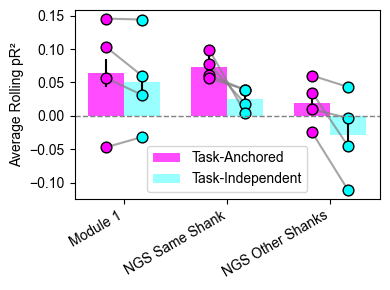

In [139]:
# Collated plot: connect task-anchored and task-independent points for each session and group
plt.figure(figsize=(4, 3))
groups = ['Module 1', 'NGS Same Shank', 'NGS Other Shanks']
width = 0.35
# Use magenta for task-anchored, cyan for task-independent
task_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}
group_colors = ['#c04744', '#1b9e77', '#7570b3']

# Plot individual session points and connect them
for g_idx, g in enumerate(groups):
    df_g = results_df[results_df['group'] == g]
    # Aggregate to ensure one row per session and task_type
    agg_df = df_g.groupby(['session', 'task_type'])['mean_pr2'].mean().unstack()
    # Only keep sessions with both types
    agg_df = agg_df.dropna(subset=[ 'Task-Anchored','Task-Independent'])
    for session, row in agg_df.iterrows():
        mouse = results_df[(results_df['session'] == session) & (results_df['group'] == g)]['mouse'].values[0]
        day = results_df[(results_df['session'] == session) & (results_df['group'] == g)]['day'].values[0]
        ti_val = row['Task-Independent']
        ta_val = row['Task-Anchored']
        print(f"Group: {g}, Mouse: {mouse}, Day: {day}, Session: {session}, TI pR²: {ti_val:.4f}, TA pR²: {ta_val:.4f}")
        
        # Connect the points for this session and group
        plt.plot([g_idx+width/2, g_idx-width/2], [row['Task-Independent'], row['Task-Anchored']],
                 color='grey', alpha=0.7, zorder=1)
        plt.scatter(g_idx+width/2, row['Task-Independent'], color=task_colors['Task-Independent'], edgecolor='k', s=60, zorder=2)
        plt.scatter(g_idx-width/2, row['Task-Anchored'], color=task_colors['Task-Anchored'], edgecolor='k', s=60, zorder=2)

# Plot summary bars as before
for i, task_type in enumerate(['Task-Anchored', 'Task-Independent']):
    df = results_df[results_df['task_type'] == task_type].groupby('group').agg({'mean_pr2': 'mean', 'sem_pr2': 'mean', 'n_cells': 'sum', 'session': 'nunique'}).reset_index()
    means = [df[df['group'] == g]['mean_pr2'].values[0] if not df[df['group'] == g].empty else np.nan for g in groups]
    sems = [df[df['group'] == g]['sem_pr2'].values[0] if not df[df['group'] == g].empty else np.nan for g in groups]
    n_sessions = [df[df['group'] == g]['session'].values[0] if not df[df['group'] == g].empty else 0 for g in groups]
    for j, g in enumerate(groups):
        n = df[df['group'] == g]['n_cells'].values[0] if not df[df['group'] == g].empty else 0
        plt.bar(j + (i-0.5)*width, means[j], width, yerr=sems[j], label=task_type if j==0 else "", alpha=0.7 if i==0 else 0.4, color=task_colors[task_type], zorder=0)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xticks(np.arange(len(groups)), groups, rotation=30, ha='right')
plt.ylabel('Average Rolling pR²')
plt.yticks([-0.1, -0.05, 0, 0.05, 0.1, 0.15])
plt.legend()
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/multishank_xgboost_taskanchoring.pdf', dpi=1000)
plt.show()

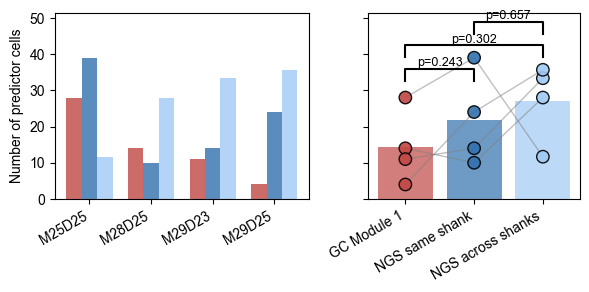

In [176]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

# Aggregate cell_count per session and group
cell_count_df = results_df.groupby(['session', 'group'])['cell_count'].mean().unstack(fill_value=0)

groups = ['Module 1', 'NGS Same Shank', 'NGS Other Shanks']
group_colors = ['#c04744', "#3171ae", "#a0caf4"]

sessions = cell_count_df.index.tolist()
x_sessions = np.arange(len(sessions))
bar_width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [1.2, 1]}, sharey=True)

# --- Left subplot: cell_count per group for each session ---
ax = axes[0]
for i, (g, color) in enumerate(zip(groups, group_colors)):
    vals = [cell_count_df.loc[s, g] if g in cell_count_df.columns else 0 for s in sessions]
    ax.bar(x_sessions + (i-1)*bar_width, vals, width=bar_width, color=color, alpha=0.8, label=g)
ax.set_xticks(x_sessions)
ax.set_xticklabels([s.replace('_', '').replace('.pkl', '') for s in sessions], rotation=30, ha='right')
ax.set_ylabel('Number of predictor cells')

# --- Right subplot: summary plot as before ---
ax = axes[1]
avg_cell_count = [cell_count_df[g].mean() if g in cell_count_df.columns else np.nan for g in groups]
x = np.arange(len(groups))
ax.bar(x, avg_cell_count, color=group_colors, alpha=0.7, label='Average cell_count')
for session in cell_count_df.index:
    yvals = [cell_count_df.loc[session, g] if g in cell_count_df.columns else np.nan for g in groups]
    ax.plot(x, yvals, color='grey', alpha=0.5, linewidth=1, zorder=1)
    ax.scatter(x, yvals, color=group_colors, edgecolor='k', s=80, zorder=2, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(['GC Module 1', 'NGS same shank', 'NGS across shanks'], rotation=30, ha='right')

# Paired t-tests between groups (annotate on right subplot)
pairs = [(0, 1), (0, 2), (1, 2)]
ymax = max(avg_cell_count) + 0.2 * max(avg_cell_count)
for idx, (i, j) in enumerate(pairs):
    mask = (~cell_count_df[groups[i]].isna()) & (~cell_count_df[groups[j]].isna())
    vals_i = cell_count_df[groups[i]][mask]
    vals_j = cell_count_df[groups[j]][mask]
    if len(vals_i) > 1 and len(vals_j) > 1:
        tstat, pval = ttest_rel(vals_i, vals_j)
        x1, x2 = x[i], x[j]
        y, h = ymax + idx*0.2*ymax, 0.1*ymax
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
        ax.text((x1+x2)/2, y+h, f'p={pval:.3g}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/multishank_session_n_units_in_predictor.pdf', dpi=1000)
plt.show()

Loaded 8 pickle files: ['M28_D23.pkl', 'M29_D25.pkl', 'M28_D25.pkl', 'M29_D23.pkl', 'M26_D15.pkl', 'M28_D17.pkl', 'M21_D16.pkl', 'M25_D25.pkl']
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
unique brain regions ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
there are 95 MEC cells
there are 30 PARA cells
there are 0 PRE cells
there are 13 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 138 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values 

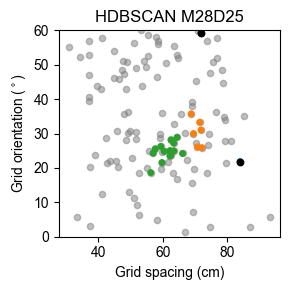

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Identified 1 candidate modules


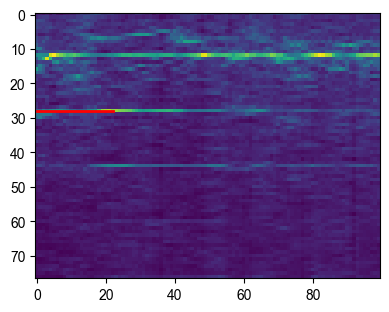

[0. 1.]
mouse 28, day 25, TA label from grid: True
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 10.95007559047365
Found 3 modules with HDBSCAN for mouse 28 day 25
for each module , the number of points is: [ 2  6 15]


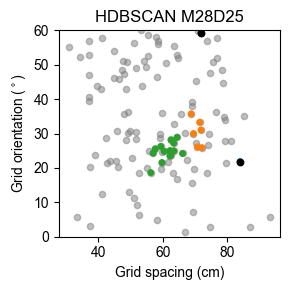

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


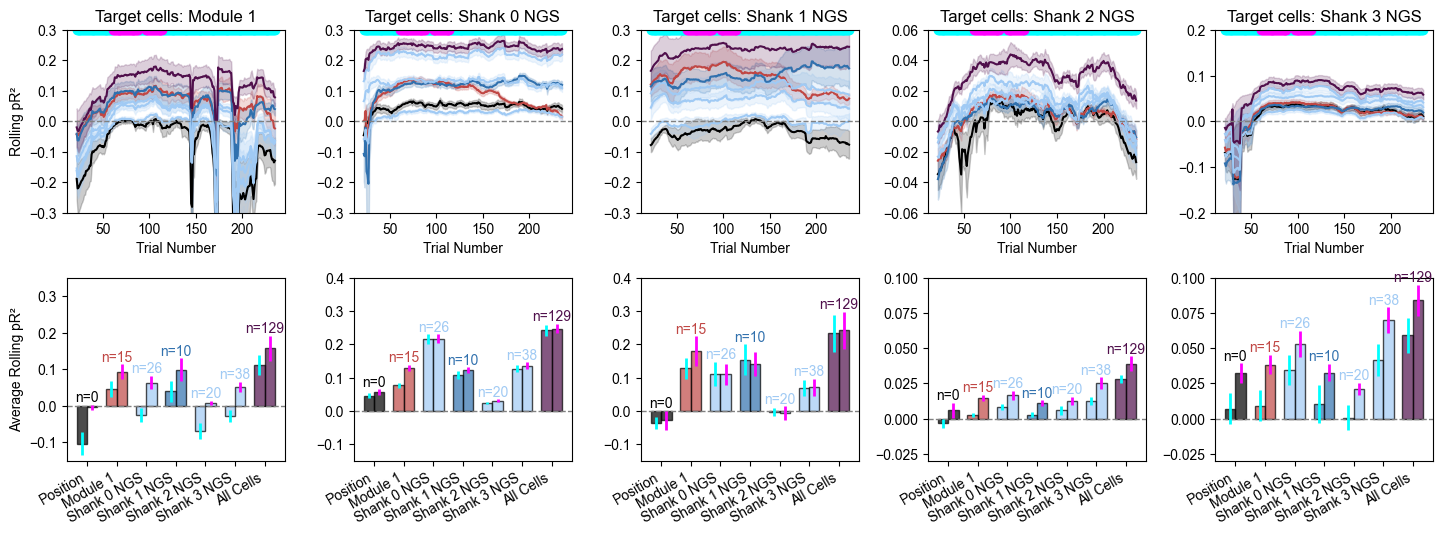

In [187]:
results_path = '/Users/harryclark/Downloads/COHORT12/multishank_xgboost/'
pkl_files = [f for f in os.listdir(results_path) if f.endswith('.pkl')]
loaded_pickles = {}
for fname in pkl_files:
    with open(os.path.join(results_path, fname), 'rb') as f:
        loaded_pickles[fname] = pickle.load(f)
print(f"Loaded {len(loaded_pickles)} pickle files:", list(loaded_pickles.keys()))

predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
]
colors = ['#000000', '#c04744', "#a0caf4", '#3171ae', '#a0caf4', '#a0caf4', '#50104c']
err_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse != 28) or (day != 25):
        continue
    trial_labels, got_from_grid = get_trial_labels(mouse, day)
    print(f'{np.unique(trial_labels)}')
    print(f'mouse {mouse}, day {day}, TA label from grid: {got_from_grid}')
    # Get cell counts for annotation
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )

    figpath_rm = f'/Users/harryclark/Desktop/M{mouse}D{day}'
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'GC', figpath=figpath_rm)
    for shank in range(4):
        plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs[ngs['shank_id'] == shank].cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'NGS Shank {shank}', figpath=figpath_rm)

    cell_counts = [
        0,  # Position (all cells)
        len(g_m_cluster_ids[0]) if len(g_m_cluster_ids) > 0 else 0,  # Module 1
        len(ngs[ngs['shank_id'] == 0]),
        len(ngs[ngs['shank_id'] == 1]),
        len(ngs[ngs['shank_id'] == 2]),
        len(ngs[ngs['shank_id'] == 3]),
        len(all.cluster_id.values),  # All cells
    ]
    groups = list(all_rolling_results_by_group.keys())
    fig, axes = plt.subplots(2, len(groups), figsize=(16/1.1, 6/1.1), sharey=False)
    # Define custom y-limits for each group
    custom_top_ylim = {
        'Module 1': (-0.3, 0.3),
        'Shank 0 NGS': (-0.3, 0.3),
        'Shank 1 NGS': (-0.3, 0.3),
        'Shank 2 NGS': (-0.06, 0.06),
        'Shank 3 NGS': (-0.2, 0.2),
    }
    custom_bottom_ylim = {
        'Module 1': (-0.15, 0.35),
        'Shank 0 NGS': (-0.15, 0.4),
        'Shank 1 NGS': (-0.15, 0.4),
        'Shank 2 NGS': (-0.03, 0.1),
        'Shank 3 NGS': (-0.03, 0.1),
    }

    for col_idx, group_name in enumerate(groups):
        group_df = all_rolling_results_by_group[group_name]
        test_ids = group_df['test_cell_id'].unique()
        ax_top = axes[0, col_idx]
        for i, pred in enumerate(predictors):
            mean_df = group_df.groupby('trial_number')[pred].mean()
            sem_df = group_df.groupby('trial_number')[pred].sem()
            ax_top.plot(mean_df.index, mean_df.values, color=colors[i], label=labels[i])
            ax_top.fill_between(mean_df.index, mean_df.values - sem_df.values, mean_df.values + sem_df.values, color=colors[i], alpha=0.2)
        ax_top.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_top.set_xlabel('Trial Number')
        ax_top.set_title(f'Target cells: {group_name}')
        # Set custom ylim for ax_top if available
        if group_name in custom_top_ylim:
            ax_top.set_ylim(custom_top_ylim[group_name])
        if col_idx == 0:
            ax_top.set_ylabel('Rolling pR²')
        else:
            ax_top.set_ylabel('')
        if trial_labels is not None:
            for label, c in zip([0,1], ['cyan', 'magenta']):
                ax_top.scatter(np.arange(mean_df.index[0], len(trial_labels) + mean_df.index[0])[trial_labels == label], np.ones(len(trial_labels))[trial_labels == label]*ax_top.get_ylim()[1], color=c)

        ax_bottom = axes[1, col_idx]
        means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
        for pred in predictors:
            vals_ti, vals_ta = [], []
            for test_id in test_ids:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
            means_ti.append(np.nanmean(vals_ti))
            means_ta.append(np.nanmean(vals_ta))
            sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
            sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
        x = np.arange(len(predictors))
        width = 0.35
        # Bar plots
        bars1 = ax_bottom.bar(
            x - width/2, means_ti, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Independent'
        )
        bars2 = ax_bottom.bar(
            x + width/2, means_ta, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Anchored'
        )
        # Manually add colored error bars
        for i in range(len(predictors)):
            ax_bottom.errorbar(
                x[i] - width/2, means_ti[i], yerr=sems_ti[i],
                fmt='none', ecolor=err_colors['Task-Independent'], elinewidth=2, capsize=0, zorder=3
            )
            ax_bottom.errorbar(
                x[i] + width/2, means_ta[i], yerr=sems_ta[i],
                fmt='none', ecolor=err_colors['Task-Anchored'], elinewidth=2, capsize=0, zorder=3
            )
        # Annotate cell counts above each bar
        for i in range(len(predictors)):
            ax_bottom.text(x[i], max(means_ti[i]+sems_ti[i], means_ta[i]+sems_ta[i]), f'n={cell_counts[i]}', ha='center', va='bottom', fontsize=10, color=colors[i])
        ax_bottom.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(labels, rotation=30, ha='right')
        # Set custom ylim for ax_bottom if available
        if group_name in custom_bottom_ylim:
            ax_bottom.set_ylim(custom_bottom_ylim[group_name])
        else:
            ax_bottom.set_ylim([-0.1, None])
        if col_idx == 0:
            ax_bottom.set_ylabel('Average Rolling pR²')
        else:
            ax_bottom.set_ylabel('')
    fig.tight_layout()
    plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M28D25_rolling_predictors.pdf')
    plt.show()

Loaded 8 pickle files: ['M28_D23.pkl', 'M29_D25.pkl', 'M28_D25.pkl', 'M29_D23.pkl', 'M26_D15.pkl', 'M28_D17.pkl', 'M21_D16.pkl', 'M25_D25.pkl']
25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
unique brain regions ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
there are 66 MEC cells
there are 47 PARA cells
there are 0 PRE cells
there are 39 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 152 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values

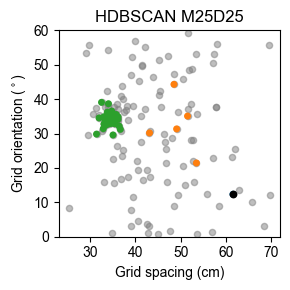

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules


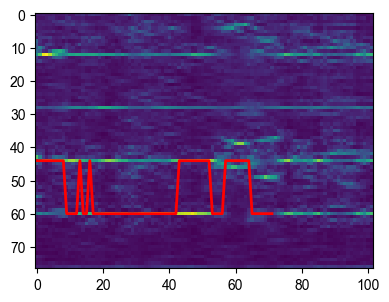

[0. 1.]
mouse 25, day 25, TA label from grid: True
25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 1  5 30]


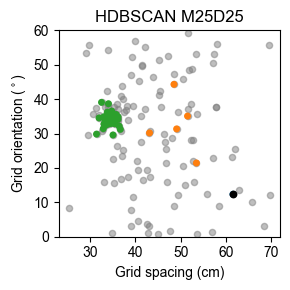

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


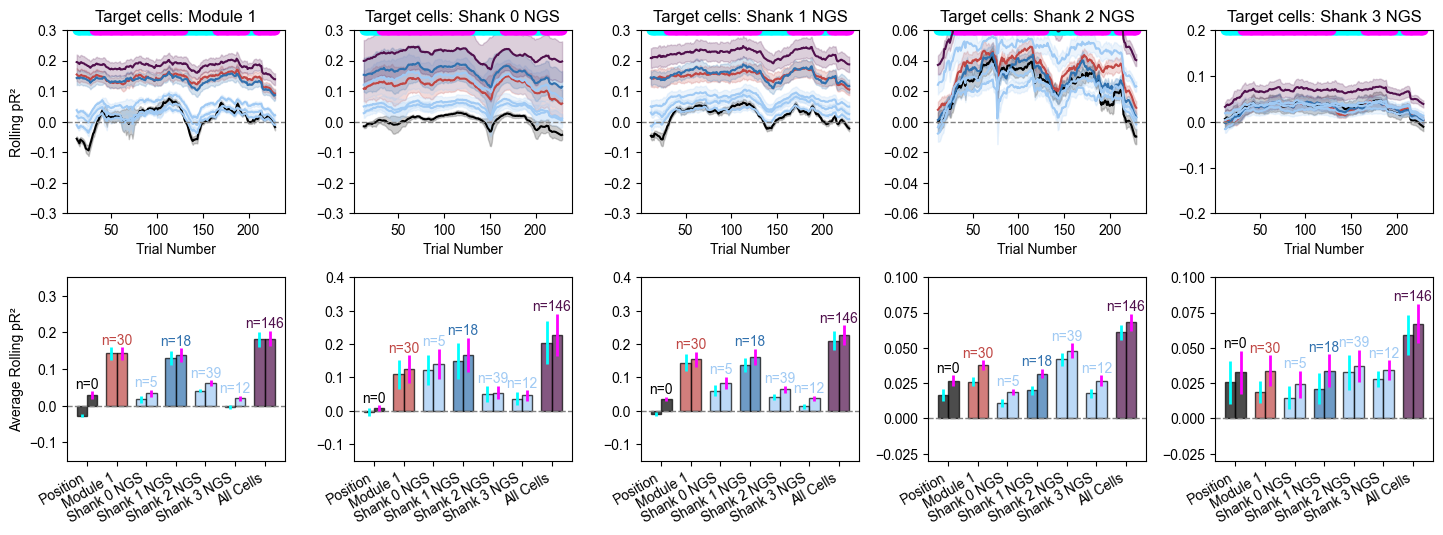

: 

In [ ]:
results_path = '/Users/harryclark/Downloads/COHORT12/multishank_xgboost/'
pkl_files = [f for f in os.listdir(results_path) if f.endswith('.pkl')]
loaded_pickles = {}
for fname in pkl_files:
    with open(os.path.join(results_path, fname), 'rb') as f:
        loaded_pickles[fname] = pickle.load(f)
print(f"Loaded {len(loaded_pickles)} pickle files:", list(loaded_pickles.keys()))

predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
]
colors = ['#000000', '#c04744', "#a0caf4", '#3171ae', '#a0caf4', '#a0caf4', '#50104c']
err_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse != 25) or (day != 25):
        continue
    trial_labels, got_from_grid = get_trial_labels(mouse, day)
    print(f'{np.unique(trial_labels)}')
    print(f'mouse {mouse}, day {day}, TA label from grid: {got_from_grid}')
    # Get cell counts for annotation
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )

    figpath_rm = f'/Users/harryclark/Desktop/M{mouse}D{day}'
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'GC', figpath=figpath_rm)
    for shank in range(4):
        plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs[ngs['shank_id'] == shank].cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'NGS Shank {shank}', figpath=figpath_rm)

    cell_counts = [
        0,  # Position (all cells)
        len(g_m_cluster_ids[0]) if len(g_m_cluster_ids) > 0 else 0,  # Module 1
        len(ngs[ngs['shank_id'] == 0]),
        len(ngs[ngs['shank_id'] == 1]),
        len(ngs[ngs['shank_id'] == 2]),
        len(ngs[ngs['shank_id'] == 3]),
        len(all.cluster_id.values),  # All cells
    ]
    groups = list(all_rolling_results_by_group.keys())
    fig, axes = plt.subplots(2, len(groups), figsize=(16/1.1, 6/1.1), sharey=False)
    # Define custom y-limits for each group
    custom_top_ylim = {
        'Module 1': (-0.3, 0.3),
        'Shank 0 NGS': (-0.3, 0.3),
        'Shank 1 NGS': (-0.3, 0.3),
        'Shank 2 NGS': (-0.06, 0.06),
        'Shank 3 NGS': (-0.2, 0.2),
    }
    custom_bottom_ylim = {
        'Module 1': (-0.15, 0.35),
        'Shank 0 NGS': (-0.15, 0.4),
        'Shank 1 NGS': (-0.15, 0.4),
        'Shank 2 NGS': (-0.03, 0.1),
        'Shank 3 NGS': (-0.03, 0.1),
    }

    for col_idx, group_name in enumerate(groups):
        group_df = all_rolling_results_by_group[group_name]
        test_ids = group_df['test_cell_id'].unique()
        ax_top = axes[0, col_idx]
        for i, pred in enumerate(predictors):
            mean_df = group_df.groupby('trial_number')[pred].mean()
            sem_df = group_df.groupby('trial_number')[pred].sem()
            ax_top.plot(mean_df.index, mean_df.values, color=colors[i], label=labels[i])
            ax_top.fill_between(mean_df.index, mean_df.values - sem_df.values, mean_df.values + sem_df.values, color=colors[i], alpha=0.2)
        ax_top.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_top.set_xlabel('Trial Number')
        ax_top.set_title(f'Target cells: {group_name}')
        # Set custom ylim for ax_top if available
        if group_name in custom_top_ylim:
            ax_top.set_ylim(custom_top_ylim[group_name])
        if col_idx == 0:
            ax_top.set_ylabel('Rolling pR²')
        else:
            ax_top.set_ylabel('')
        if trial_labels is not None:
            for label, c in zip([0,1], ['cyan', 'magenta']):
                ax_top.scatter(np.arange(mean_df.index[0], len(trial_labels) + mean_df.index[0])[trial_labels == label], np.ones(len(trial_labels))[trial_labels == label]*ax_top.get_ylim()[1], color=c)

        ax_bottom = axes[1, col_idx]
        means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
        for pred in predictors:
            vals_ti, vals_ta = [], []
            for test_id in test_ids:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
            means_ti.append(np.nanmean(vals_ti))
            means_ta.append(np.nanmean(vals_ta))
            sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
            sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
        x = np.arange(len(predictors))
        width = 0.35
        # Bar plots
        bars1 = ax_bottom.bar(
            x - width/2, means_ti, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Independent'
        )
        bars2 = ax_bottom.bar(
            x + width/2, means_ta, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Anchored'
        )
        # Manually add colored error bars
        for i in range(len(predictors)):
            ax_bottom.errorbar(
                x[i] - width/2, means_ti[i], yerr=sems_ti[i],
                fmt='none', ecolor=err_colors['Task-Independent'], elinewidth=2, capsize=0, zorder=3
            )
            ax_bottom.errorbar(
                x[i] + width/2, means_ta[i], yerr=sems_ta[i],
                fmt='none', ecolor=err_colors['Task-Anchored'], elinewidth=2, capsize=0, zorder=3
            )
        # Annotate cell counts above each bar
        for i in range(len(predictors)):
            ax_bottom.text(x[i], max(means_ti[i]+sems_ti[i], means_ta[i]+sems_ta[i]), f'n={cell_counts[i]}', ha='center', va='bottom', fontsize=10, color=colors[i])
        ax_bottom.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(labels, rotation=30, ha='right')
        # Set custom ylim for ax_bottom if available
        if group_name in custom_bottom_ylim:
            ax_bottom.set_ylim(custom_bottom_ylim[group_name])
        else:
            ax_bottom.set_ylim([-0.1, None])
        if col_idx == 0:
            ax_bottom.set_ylabel('Average Rolling pR²')
        else:
            ax_bottom.set_ylabel('')
    fig.tight_layout()
    plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M28D25_rolling_predictors.pdf')
    plt.show()